   transaction_id  customer_id  transaction_amount payment_method  \
0               1         8842             2462.19            UPI   
1               2         5639             1497.21    Net Banking   
2               3         9446             1147.22            UPI   
3               4         8958              868.23            UPI   
4               5         9236             2167.59    Net Banking   

      location device_type     transaction_time  is_fraud  
0  Michaelbury      Mobile  2026-05-18 08:29:00         0  
1   Littleside      Mobile  2026-05-09 18:26:24         0  
2   Garciatown      Mobile  2026-05-02 20:49:52         1  
3     Fryburgh      Tablet  2026-05-01 08:36:18         0  
4   East Sarah      Laptop  2026-05-09 14:49:34         0  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   transaction_id   

C:\Users\Riyaz\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\Riyaz\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\Riyaz\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


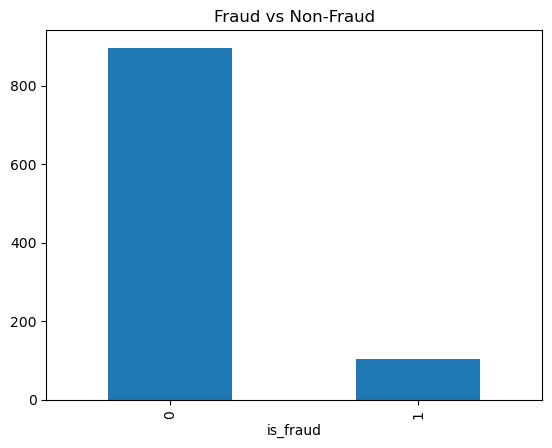

In [1]:

import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix

df=pd.read_csv("fraud_transactions.csv")

print(df.head())
print(df.info())

df=df.drop_duplicates()

encoder=LabelEncoder()
for col in ["payment_method","location","device_type"]:
    df[col]=encoder.fit_transform(df[col])

X=df.drop(["transaction_id","transaction_time","is_fraud"],axis=1)
y=df["is_fraud"]

X_train,X_test,y_train,y_test=train_test_split(
X,y,test_size=0.2,random_state=42)

model=RandomForestClassifier()
model.fit(X_train,y_train)

pred=model.predict(X_test)

print(classification_report(y_test,pred))
print(confusion_matrix(y_test,pred))

fraud_count=df["is_fraud"].value_counts()
fraud_count.plot(kind="bar")
plt.title("Fraud vs Non-Fraud")
plt.show()
